In [31]:
from ctypes.wintypes import MSG

Name = Nishan khatiwoda
student id = 2601767

SyntaxError: invalid syntax (2808584102.py, line 1)

In [ ]:
# Select the data file based on your student ID
n = 2601767 % 5 # Take the modulo 5 of your student ID
num_list = [3, 4, 6, 8, 9] # List of numbers to select from
filename = f'./data/bidmc_{num_list[n]:02d}_Signals.csv'
print(f'Filename: {filename}')

In [ ]:
# Run if needed
#%pip install numpy pandas matplotlib scipy

In [ ]:
# Read necessary libraries and functions
import numpy as np                  # for numerical operations
import matplotlib.pyplot as plt     # for plotting
import pandas as pd                 # for reading data
from scipy.signal import find_peaks # for peak detection
import os                           # for file operations'


In [ ]:
# Print the list of files in the ./data directory
os.listdir('./data')

In [ ]:
# Read the data
data = pd.read_csv(filename)

# Get PPG signal and create time vector
ppg = data[' PLETH']
ts = 0.008 # Sample time in seconds
fs = 1/ts # Sample rate (Hz), samples per second
t = np.arange(len(ppg))*ts

In [ ]:
# Plot 180 seconds of the full signal
plt.figure(figsize = (10, 3))
plt.plot(t, ppg)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'File: {filename}')
plt.xlim(0, 180)
plt.grid()
plt.show()

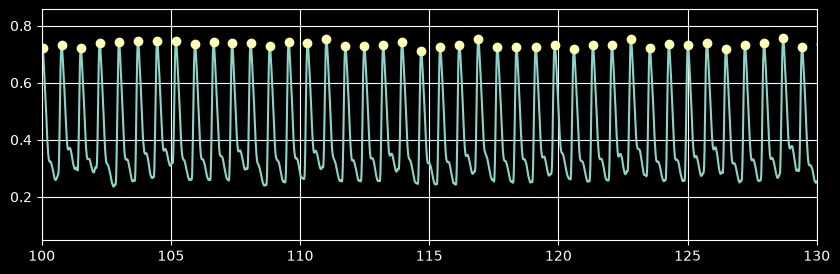

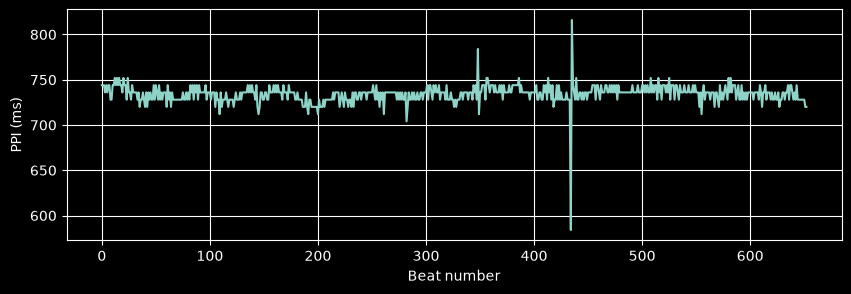

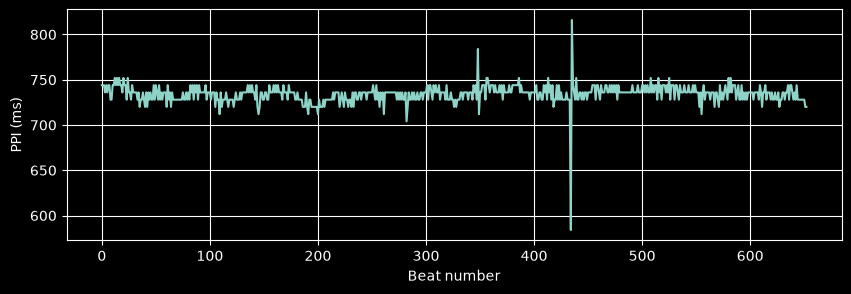

Mean PPI: 734.27 ms
Mean HR: 81.71 bpm
SDNN: 10.29 ms
RMSSD: 14.92 ms


In [33]:
# Remove physiologically implausible PPI values
# Continue coding here ...
peaks, properties = find_peaks(ppg, height=0.5, distance=50)

plt.figure(figsize=(10, 3))
plt.plot(t, ppg)
plt.plot(t[peaks], ppg[peaks], 'o')
plt.xlim(100, 130)
plt.grid()
plt.show()
ppi = np.diff(peaks) * ts * 1000

plt.figure(figsize=(10, 3))
plt.plot(ppi)
plt.xlabel("Beat number")
plt.ylabel("PPI (ms)")
plt.grid()
plt.show()
ppi = ppi[(ppi > 500) & (ppi < 900)]

plt.figure(figsize=(10, 3))
plt.plot(ppi)
plt.xlabel("Beat number")
plt.ylabel("PPI (ms)")
plt.grid()
plt.show()
mean_ppi = np.mean(ppi)
mean_hr = 60000 / mean_ppi
sdnn = np.std(ppi)
rmssd = np.sqrt(np.mean(np.diff(ppi)**2))

print("Mean PPI:", round(mean_ppi, 2), "ms")
print("Mean HR:", round(mean_hr, 2), "bpm")
print("SDNN:", round(sdnn, 2), "ms")
print("RMSSD:", round(rmssd, 2), "ms")

In [32]:
# Remember to add your interpretations ...
The patient is a 64 year old female.
 1.The mean heart rate is 81.71 bpm. It falls within the range 60-100 bpm, hence mean heart rate cannot be said to be very high or very low.

 2.Average value of Pulse to Pulse Interval (PPI) is 734.27 ms which is equal to Heart Rate of 81.71 BPM. Therefore, it can be said that the average PPI is within normal range.

 3.The SDNN was 10.29 MS and RMSSD was 14.92 MS

 4. The variation was low because both SDNN and RMSSD values are relatively low.

 5. As per the lecture notes, the patient in question is a 64-year-old woman who has been entered into the MICU. While her heart rate is 81.71 BPM and is in the range for adults, the SDNN 10.29 MS and RMSSD 14.92 MS indicate low HRV. Hence, it can be concluded that the patient might be under stress..